In [1]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone

In [2]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp500 = market.retrieve("sp500")
market.disconnect()

In [3]:
holding_period = 65
tickers = sp500["ticker"].values
positions = 10
training_year = datetime.now().year - 10
today = datetime.now()
week = today.isocalendar()[1]
weekday = today.weekday()
week_mod = int(week % (holding_period/5))
print(week_mod,week)

11 50


In [4]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        simulation = ticker_prices.copy()
        simulation.sort_values("date",inplace=True)
        simulation["return"] = (simulation["adjclose"] - simulation["adjclose"].shift(holding_period*2)) / simulation["adjclose"].shift(holding_period*2)
        simulation["risk"] = simulation["adjclose"].rolling(holding_period*2).std() / simulation["adjclose"].rolling(holding_period*2).mean()
        simulation["abs"] = simulation["return"] / simulation["risk"]
        simulation["buy_price"] = simulation["adjclose"].shift(-1)
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"].shift(-holding_period)
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"]
        prices.append(simulation)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  13%|█▎        | 65/503 [00:09<00:52,  8.30it/s]

'date'


model_prep:  16%|█▌        | 81/503 [00:11<00:51,  8.24it/s]

'date'


model_prep: 100%|██████████| 503/503 [01:13<00:00,  6.85it/s]

'date'


In [5]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp500,on="ticker")

In [6]:
## backtest
trades = sim[sim["weekday"]==weekday-1].copy()
trades = trades[trades["week"] % int(holding_period/5) == week_mod]
trades = trades.sort_values("abs",ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()

In [7]:
trades = processor.column_date_processing(trades[["date","abs","ticker","GICS Sector","adjclose","return"]])

In [8]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio["year"] = [x.year for x in portfolio["date"]]
portfolio = portfolio[(portfolio["date"]<portfolio["date"].max())]
portfolio["return"] = portfolio["return"] * (1/positions) + 1
portfolio["cr"] = portfolio["return"].cumprod()

In [9]:
fed.connect()
bench = fed.retrieve("sp500")
fed.disconnect()
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench,on="date")
portfolio.dropna(inplace=True)
portfolio["bcr"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1

In [10]:
portfolio

,date,return,year,cr,quarter,month,week,weekday,realtime_start,realtime_end,value,bcr
0,2014-03-10 00:00:00+00:00,1.063136,2014,1.063136,1,3,11,0,2023-12-10,2023-12-10,1877.17,1.000000
1,2014-06-09 00:00:00+00:00,0.998959,2014,1.062029,2,6,24,0,2023-12-10,2023-12-10,1951.27,1.039474
2,2014-09-08 00:00:00+00:00,1.053727,2014,1.119089,3,9,37,0,2023-12-10,2023-12-10,2001.54,1.066254
3,2014-12-08 00:00:00+00:00,1.022887,2014,1.144702,4,12,50,0,2023-12-10,2023-12-10,2060.31,1.097562
4,2015-03-09 00:00:00+00:00,1.072762,2015,1.227993,1,3,11,0,2023-12-10,2023-12-10,2079.43,1.107747
5,2015-06-08 00:00:00+00:00,0.938620,2015,1.152619,2,6,24,0,2023-12-10,2023-12-10,2079.28,1.107667
6,2015-12-07 00:00:00+00:00,0.993039,2015,1.144597,4,12,50,0,2023-12-10,2023-12-10,2077.07,1.106490
7,2016-03-14 00:00:00+00:00,1.099967,2016,1.259019,1,3,11,0,2023-12-10,2023-12-10,2019.64,1.075896
8,2016-06-13 00:00:00+00:00,0.957307,2016,1.205268,2,6,24,0,2023-12-10,2023-12-10,2079.06,1.107550
9,2016-09-12 00:00:00+00:00,1.111993,2016,1.340250,3,9,37,0,2023-12-10,2023-12-10,2159.04,1.150157


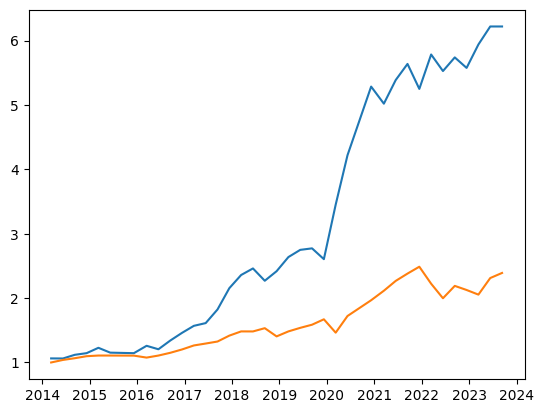

In [11]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [12]:
recommendations = trades.sort_values(["date","abs"]).tail(positions)

In [13]:
recommendations

,date,abs,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
109,2023-12-11 00:00:00+00:00,5.273892,COST,Consumer Staples,623.86,NaN,2023,4,12,50,0
85,2023-12-11 00:00:00+00:00,5.384652,NTAP,Information Technology,89.75,NaN,2023,4,12,50,0
72,2023-12-11 00:00:00+00:00,5.432259,FDX,Industrials,271.38,NaN,2023,4,12,50,0
56,2023-12-11 00:00:00+00:00,5.583891,TMUS,Communication Services,158.85,NaN,2023,4,12,50,0
52,2023-12-11 00:00:00+00:00,5.625625,ADBE,Information Technology,625.20,NaN,2023,4,12,50,0
50,2023-12-11 00:00:00+00:00,5.652564,APH,Information Technology,95.24,NaN,2023,4,12,50,0
26,2023-12-11 00:00:00+00:00,6.057194,LULU,Consumer Discretionary,502.74,NaN,2023,4,12,50,0
25,2023-12-11 00:00:00+00:00,6.089231,AVGO,Information Technology,1029.24,NaN,2023,4,12,50,0
24,2023-12-11 00:00:00+00:00,6.114402,URI,Industrials,505.14,NaN,2023,4,12,50,0
10,2023-12-11 00:00:00+00:00,6.548732,PCAR,Industrials,97.93,NaN,2023,4,12,50,0


In [14]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()